In [2]:
# Install dependencies
!pip install git+https://github.com/openai/CLIP.git
!pip install torch torchvision --upgrade
!pip install segment_anything

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-bid_wzs2
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-bid_wzs2
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 115.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Base SAM weights

In [3]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2025-05-25 14:54:58--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.163.24.72, 3.163.24.93, 3.163.24.87, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.163.24.72|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   113MB/s    in 3.2s    

2025-05-25 14:55:01 (113 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



Large SAM weights, not using them because they are heavy

In [ ]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth

--2025-05-23 18:07:42--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.163.189.96, 3.163.189.14, 3.163.189.51, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.163.189.96|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1249524607 (1.2G) [binary/octet-stream]
Saving to: ‘sam_vit_l_0b3195.pth’

sam_vit_l_0b3195.pt 100%[===================>]   1.16G   251MB/s    in 8.1s    

2025-05-23 18:07:50 (146 MB/s) - ‘sam_vit_l_0b3195.pth’ saved [1249524607/1249524607]



In [4]:
# Imports
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator
import numpy as np
from PIL import Image
import torch
import clip
import cv2

In [5]:
# 1. Load models
device = "cuda" if torch.cuda.is_available() else "cpu"

sam_checkpoint = "sam_vit_b_01ec64.pth" # other options are sam_vit_l_0b3195.pth, sam_vit_b_01ec64.pth
model_type = "vit_b"
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint).to(device)
#mask_generator = SamAutomaticMaskGenerator(sam)
mask_generator = SamAutomaticMaskGenerator( #reducing the number of points prompts makes it more time efficient (using a lot of the RAM)
        sam,
        points_per_side=16,          # Reduce point density
        pred_iou_thresh=0.9,         # Increase quality threshold
        stability_score_thresh=0.92, # Increase stability threshold
        min_mask_region_area=2000,   # Set a minimum area for masks

        crop_n_layers=0,

)
model_clip, preprocess = clip.load('ViT-B/32', device=device)


100%|███████████████████████████████████████| 338M/338M [00:09<00:00, 38.7MiB/s]


In [6]:
# 2. Function to make the detected object cropped (same as YOLO)
def mask_and_preprocess(img: Image.Image, mask: np.ndarray):
    arr = np.array(img).astype(np.uint8)
    white_bg = np.ones_like(arr) * 255
    masked = np.where(mask[..., None], arr, white_bg)
    pil = Image.fromarray(masked)
    return preprocess(pil).unsqueeze(0).to(device)

In [7]:
# 3. Function to visualize the mask detected by SAM, from lab practice

import numpy as np
import matplotlib.pyplot as plt

def visualize_sam_masks(img, masks):

    if len(masks) == 0:
        print("No masks to display.")
        return

    # I have seen is typical to sort the masks by area
    sorted_masks = sorted(masks, key=lambda x: x['area'], reverse=True)

    # Overlay image for visualization
    h, w = sorted_masks[0]['segmentation'].shape
    overlay = np.ones((h, w, 4))
    overlay[:, :, 3] = 0

    # overlay every detected mask
    for mask in sorted_masks:
        seg = mask['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])  # Semi-transparent RGBA
        overlay[seg] = color_mask

    # Plot image with overlay
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.imshow(overlay)
    plt.axis('off')
    plt.title("SAM Segmentation Masks")
    plt.show()


In [8]:
# 4. Function to run SAM model on image and get the detected masks
def mask(img_path: str):
    # Load and resize
    img = Image.open(img_path).convert("RGB")
    img_cv = cv2.resize(np.array(img), (860, 720), interpolation=cv2.INTER_AREA) # due to the long executing time, i am reducing the image so is quicker, original image is too big
    img = Image.fromarray(img_cv)

    # Generate masks automatically
    masks = mask_generator.generate(img_cv)

    visualize_sam_masks(img_cv, masks)
    return masks

In [9]:
# 5. selection function with prompts using CLIP after SAM segmentation

def mask_by_prompt(img_path: str, prompt: str, masks):
    # Load and resize
    img = Image.open(img_path).convert("RGB")
    img_cv = cv2.resize(np.array(img), (860, 720), interpolation=cv2.INTER_AREA)
    img = Image.fromarray(img_cv)

    # CLIP Part
    text_tokens = clip.tokenize([prompt]).to(device) #we first tokenize the text prompts
    with torch.no_grad():
        text_feat = model_clip.encode_text(text_tokens) #and then we encode them
        text_feat /= text_feat.norm(dim=-1, keepdim=True) #normalization to make sure then we perform cosine similarity

    #define variables to save the best score (similarity) and mask and bbox
    best_score = -1
    best_mask = None
    best_bbox = None

    # Check all the masks to find the most similar to the prompt
    for m in masks:
        mask_bool = m["segmentation"]  #the mask is boolean

        # now we apply CLIP on masked (cropped)
        img_input = mask_and_preprocess(img, mask_bool) #we cropped the object with the mask

        #same pipeline as followed with YOLO
        with torch.no_grad():
            img_feat = model_clip.encode_image(img_input)
            img_feat /= img_feat.norm(dim=-1, keepdim=True)
            score = (img_feat @ text_feat.T).item()

        if score > best_score:
            best_score = score
            best_mask = mask_bool
            if "bbox" in m:
                best_bbox = m["bbox"]
            else:
                ys, xs = np.where(mask_bool)
                best_bbox = [xs.min(), ys.min(), xs.max() - xs.min(), ys.max() - ys.min()]


    # Overlay mask
    overlay = Image.new('RGBA', img.size, (255, 0, 0, 0))
    if best_mask is not None:
        mask_pil = Image.fromarray((best_mask * 255).astype(np.uint8), mode='L')
        red = Image.new('RGBA', img.size, (255, 0, 0, 80))
        overlay = Image.composite(red, overlay, mask_pil)

    result = Image.alpha_composite(img.convert('RGBA'), overlay)

    # Draw bounding box and label
    if best_bbox is not None:
        draw = ImageDraw.Draw(result)
        x, y, w, h = best_bbox
        draw.rectangle([x, y, x + w, y + h], outline='yellow', width=4)
        draw.text((x, y - 10), "Best match", fill='yellow')
    return result, best_score


In [17]:
# 6. Filtering 1 class, the one written in the filtering prompt

from PIL import Image, ImageDraw
import numpy as np
import torch
import clip
import cv2
from PIL import Image,ImageDraw, ImageFont

# ? It does not seem to work
font_size = 150
try:
        font = ImageFont.truetype("arialbd.ttf", font_size)

except:
        font = ImageFont.load_default()


def masks_by_prompt_all(img_path: str, prompt: str, masks, threshold=0.25):
    # Load and resize
    img = Image.open(img_path).convert("RGB")
    img_cv = cv2.resize(np.array(img), (860, 720), interpolation=cv2.INTER_AREA)
    img = Image.fromarray(img_cv)

    # Encode text
    text_tokens = clip.tokenize([prompt]).to(device)
    with torch.no_grad():
        text_feat = model_clip.encode_text(text_tokens)
        text_feat /= text_feat.norm(dim=-1, keepdim=True)

    # Output masks that pass threshold, this value has been selected because a higher one does not seem to work well
    selected = []

    for m in masks:
        mask_bool = m["segmentation"]
        img_input = mask_and_preprocess(img, mask_bool)

        with torch.no_grad():
            img_feat = model_clip.encode_image(img_input)
            img_feat /= img_feat.norm(dim=-1, keepdim=True)
            score = (img_feat @ text_feat.T).item()

        if score >= threshold:
            # Get bounding box
            if "bbox" in m:
                bbox = m["bbox"]
            else:
                ys, xs = np.where(mask_bool)
                bbox = [xs.min(), ys.min(), xs.max() - xs.min(), ys.max() - ys.min()]
            selected.append((mask_bool, score, bbox))

    # Overlay all selected masks
    overlay = Image.new('RGBA', img.size, (255, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)

    for mask_bool, score, bbox in selected:
        mask_pil = Image.fromarray((mask_bool * 255).astype(np.uint8), mode='L')
        red = Image.new('RGBA', img.size, (255, 0, 0, 80))
        overlay = Image.composite(red, overlay, mask_pil)

    result = Image.alpha_composite(img.convert('RGBA'), overlay)

    # Draw boxes and labels
    draw = ImageDraw.Draw(result)
    for _, score, bbox in selected:
        x, y, w, h = bbox
        draw.rectangle([x, y, x + w, y + h], outline='yellow', width=4)
        draw.text((x, y - 10), f"{prompt} ({score:.2f})", fill='yellow',font=font)

    return result, selected


In [12]:
# 7. After filtering 1 class, we classify the objects with a set of prompts, assigning the most similar one with CLIP

def classify_books_by_subprompt(img_path: str, base_prompt: str, sub_prompts: list, masks, threshold=0.25):
    # Find all base-class masks
    result_img, matched = masks_by_prompt_all(img_path, base_prompt, masks, threshold)

    img = Image.open(img_path).convert("RGB")
    img = img.resize((860, 720), Image.BILINEAR)

    #T okenize all sub-prompts
    text_tokens = clip.tokenize(sub_prompts).to(device)
    with torch.no_grad():
        text_feats = model_clip.encode_text(text_tokens)
        text_feats /= text_feats.norm(dim=-1, keepdim=True)

    #  For each object, classify it with sub-prompts
    overlay = Image.new('RGBA', img.size, (255, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)

    result = img.convert('RGBA')
    draw_result = ImageDraw.Draw(result)

    #Visualization
    for mask_bool, _, bbox in matched:
        img_input = mask_and_preprocess(img, mask_bool)
        with torch.no_grad():
            img_feat = model_clip.encode_image(img_input)
            img_feat /= img_feat.norm(dim=-1, keepdim=True)

        sims = (img_feat @ text_feats.T).squeeze(0).cpu().numpy()
        best_idx = np.argmax(sims)
        best_label = sub_prompts[best_idx]
        best_score = sims[best_idx]

        # Draw overlay and label
        mask_pil = Image.fromarray((mask_bool * 255).astype(np.uint8), mode='L')
        red = Image.new('RGBA', img.size, (255, 0, 0, 80))
        overlay = Image.composite(red, overlay, mask_pil)

        x, y, w, h = bbox
        draw_result.rectangle([x, y, x + w, y + h], outline='cyan', width=4)
        draw_result.text((x, y - 10), f"{best_label} ({best_score:.2f})", fill='cyan', font=font)

    final_result = Image.alpha_composite(result, overlay)
    return final_result


In [13]:
#More imports
from google.colab import drive
import cv2
import numpy as np
from PIL import Image,ImageDraw, ImageFont
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import os
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
PHOTO PATHS

In [ ]:
image_path = 'Images/Object_Setup.jpeg'

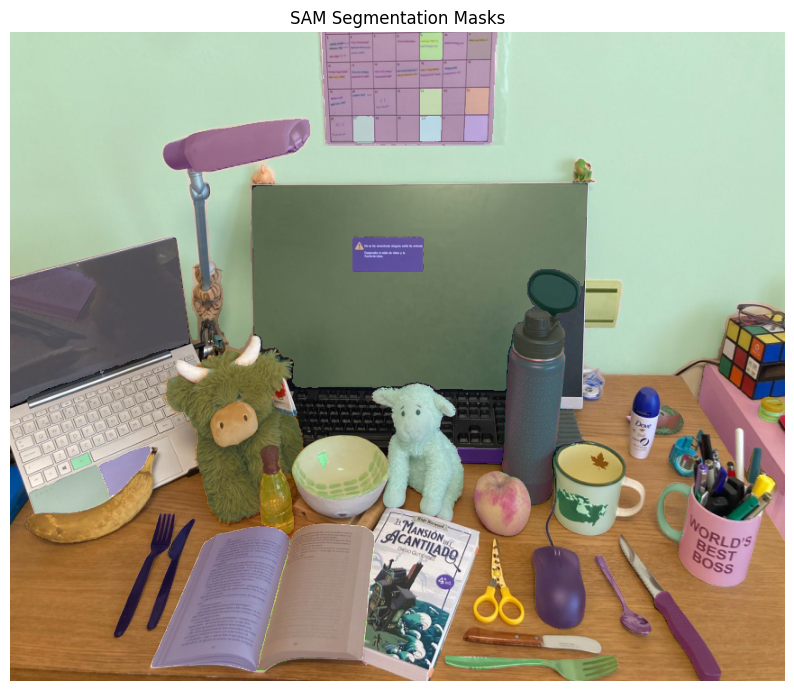

In [15]:
# Get SAM segmentation masks
mask_results = mask(image_path)

Best match score: 0.2888


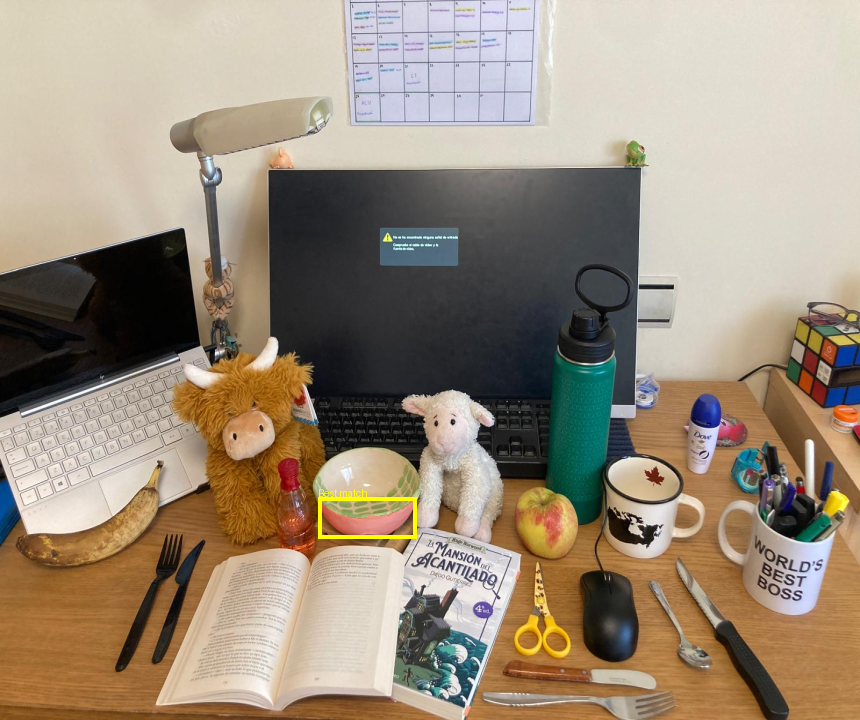

In [29]:

prompt = 'a white object'

result_img, score = mask_by_prompt(image_path, prompt, mask_results)
print(f"Best match score: {score:.4f}")
result_img

CHOOSE CLASS TO FILTER AND THEN WRITE VARIOUS PROMPTS TO GET THE BEST DESCRIPTION OF THE FILTERED OBJECTS

In [ ]:
# Filter by one class
prompt = 'teddy bear'

result_img, score = masks_by_prompt_all(image_path, prompt, mask_results)
result_img

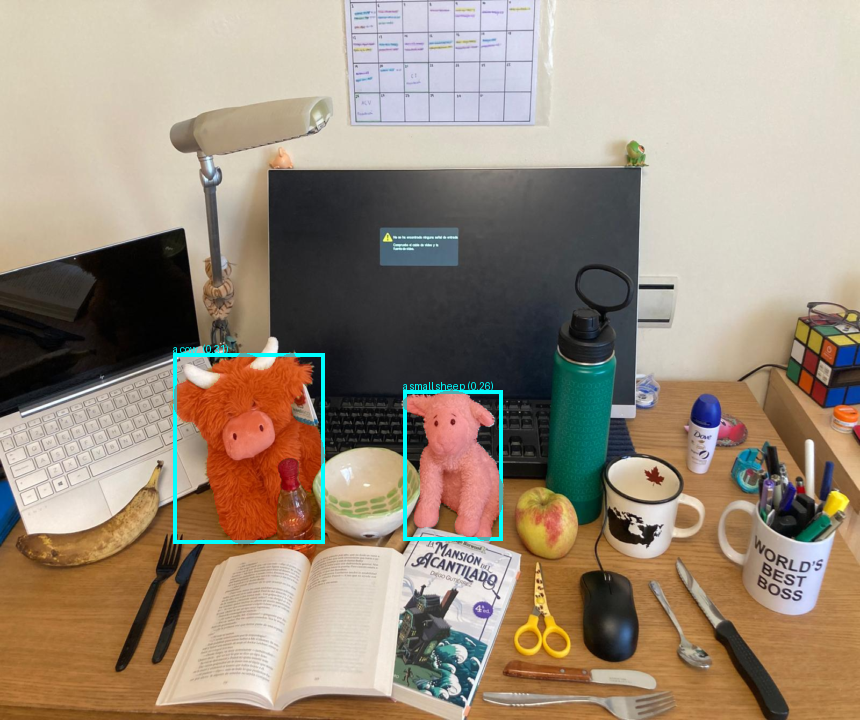

In [24]:
#sub_prompts = ["a cow ","a sheep", "a brown cow", "a white sheep", "a stuffed sheep", "a stuffed cow", "a fluffy white sheep", "a fluffy brown cow","a fluffy sheep", "a fluffy cow", "a cute sheep", "a cute cow", "a tagged animal" ]
#sub_prompts = ["a cow ","a white animal", "a brown cow"]
sub_prompts = ["a cow ","a sheep", "a small sheep", "a big sheep"]
#sub_prompts = ["a cow ","an animal similar to a cloud", "a brown cow", "a big sheep"]

#sub_prompts = ["a closed book ","an open book", "a book cover", "a book fourth edition", "a soft cover book", "la mansion del acantilado book", "a child book", "a teenager book"]

#sub_prompts =["a plastic knife ","a silver knife"]


final_img = classify_books_by_subprompt(
    image_path,
    base_prompt=prompt,
    sub_prompts=sub_prompts,
    masks=mask_results,
    threshold=0.25
)

final_img